In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sqlalchemy import create_engine

Loading the master cleaned CSV file

In [86]:
master_df = pd.read_csv('../data/olist_master_clean.csv')

Converting into datetime object

In [87]:
master_df['order_purchase_timestamp'] = pd.to_datetime(master_df['order_purchase_timestamp'])

1.We consider a customer to be Churned/Inactive if they had not made a purchase for more than a certain number of days

Finding the latest date in the dataset

In [88]:
max_date = master_df['order_purchase_timestamp'].max()

Calculating how many days ago each customer last made a purchase

In [89]:
customer_recency = master_df.groupby('customer_unique_id')['order_purchase_timestamp'].max().reset_index()
customer_recency['recency_days'] = (max_date - customer_recency['order_purchase_timestamp']).dt.days

We define Churn if there has been no purchase for more than 180 days, Churned = 1, otherwise 0

In [90]:
customer_recency['is_churned'] = customer_recency['recency_days'].apply(lambda x : 1 if x > 180 else 0) 

Calculating  Churn Rate

In [91]:
churn_rate = customer_recency['is_churned'].value_counts(normalize=True) * 100

Making a Graphical visualation

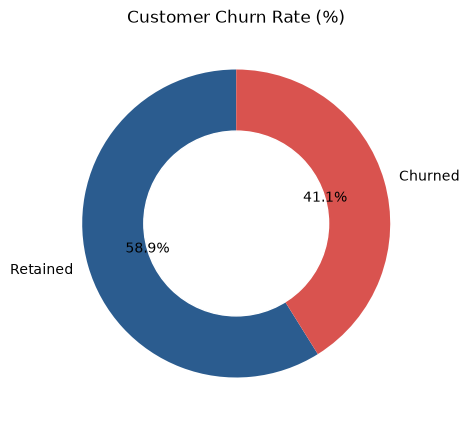

In [92]:
plt.figure(figsize=(5, 5))
plt.pie(
    churn_rate, 
    labels=['Retained', 'Churned'], 
    autopct='%1.1f%%', 
    colors=['#2b5c8f', '#d9534f'],
    startangle=90
)
plt.gca().add_artist(plt.Circle((0,0), 0.6, color='white'))

plt.title('Customer Churn Rate (%)')
plt.show()

Insight: Analysis reveals a 58.9% churn rate, indicating that retention strategies should target customers after their first 60 days of inactivity.

2.Impact of Delievery on churn.


Let's see if delievery took longer for Churned Customers

Average delievery days for Churned/Active Customers

In [93]:
master_df = master_df.merge(customer_recency[['customer_unique_id', 'is_churned']], on = 'customer_unique_id', how = 'left')
avg_del_days = master_df.groupby('is_churned')[['delivery_time_days', 'estimated_vs_actual_days']].mean()

In [94]:
avg_del_days

,delivery_time_days,estimated_vs_actual_days
is_churned,,
0,10.864298,11.187282
1,13.446153,11.585210


Making a Graphical visualation

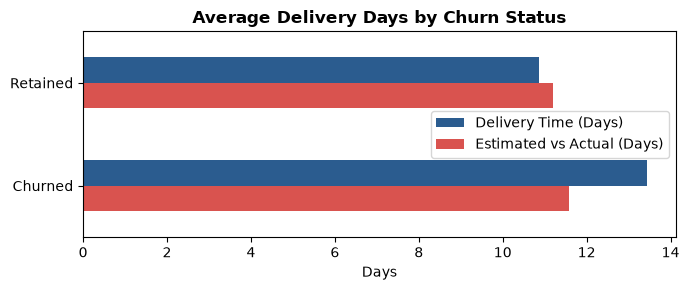

In [95]:
avg_del_days.index = ['Retained', 'Churned']
ax = avg_del_days.plot(kind = 'barh', figsize=(7, 3), color=['#2b5c8f', '#d9534f'])

plt.title('Average Delivery Days by Churn Status', weight='bold')
plt.xlabel('Days')
plt.legend(['Delivery Time (Days)', 'Estimated vs Actual (Days)'])

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Insight:

Churned customers experienced an average actual delivery time of 13.4 days compared to 10.9 days for retained customers—a ~2.6-day delay that strongly correlates with customer churn.

3.The Impact of Payment method on Churn

Let's see which payment method users are most likely to churn

In [96]:
by_payment_type = master_df.groupby('primary_payment_type')['is_churned'].mean()*100

In [97]:
by_payment_type

primary_payment_type
boleto         61.427548
credit_card    58.078073
debit_card     39.430648
voucher        64.022663
Name: is_churned, dtype: float64

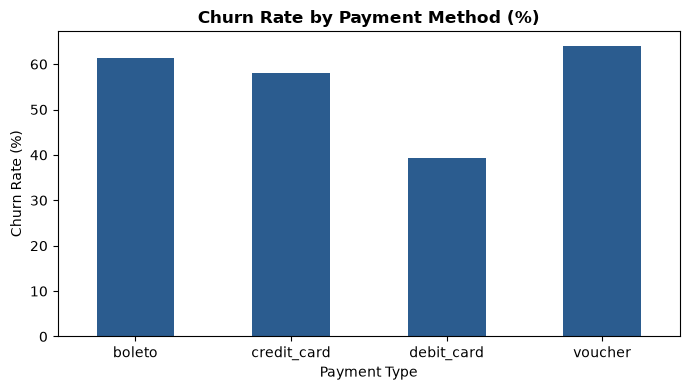

In [98]:
ax = by_payment_type.plot(kind='bar', figsize=(7, 4), color='#2b5c8f', rot=0)

plt.title('Churn Rate by Payment Method (%)', weight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Payment Type')

plt.tight_layout()
plt.show()

Insight:

Customers who complete purchases using discount vouchers or gift cards display the lowest brand loyalty and are the most likely to abandon the platform after a single transaction.

Actionable Strategy:

Avoid relying on one-off promotional vouchers for new customer acquisition without a follow-up retention workflow (e.g., targeted email onboarding or secondary purchase discounts).

4.The Impact of installments on Churn

In [99]:
avg_max_payment_installments = master_df.groupby('max_payment_installments')['is_churned'].mean().reset_index()
avg_max_payment_installments

,max_payment_installments,is_churned
0,0.0,0.000000
1,1.0,0.577152
2,2.0,0.571290
3,3.0,0.597696
4,4.0,0.600154
5,5.0,0.604699
6,6.0,0.602000
7,7.0,0.619128
8,8.0,0.529640
9,9.0,0.678977


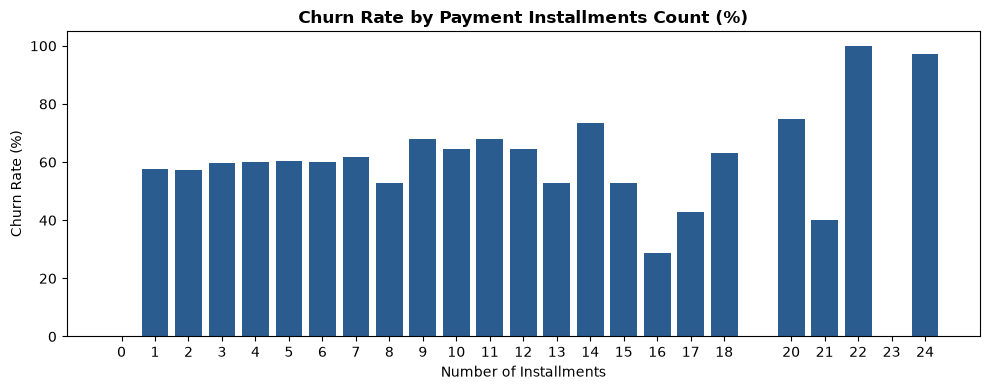

In [100]:
plot_df = avg_max_payment_installments.copy()
plot_df['churn_pct'] = plot_df['is_churned'] * 100

plt.figure(figsize=(10, 4))
plt.bar(plot_df['max_payment_installments'], plot_df['churn_pct'], color='#2b5c8f')


plt.title('Churn Rate by Payment Installments Count (%)', weight='bold')
plt.xlabel('Number of Installments')
plt.ylabel('Churn Rate (%)')
plt.xticks(plot_df['max_payment_installments'].astype(int))

plt.tight_layout()
plt.show()

Insight:

1–3 Installments: Represents the core retention base with the lowest churn (~57%)

10+ Installments: Churn climbs up to ~68%, demonstrating that long-term financing attracts single-purchase buyers for high-ticket items rather than recurring, loyal customers.

5.Calculating the number of orders for each customer

In [101]:
orders_per_customer = master_df.groupby('customer_unique_id')['order_id'].nunique().reset_index()
orders_per_customer.columns = ['customer_unique_id','order count']

In [102]:
orders_per_customer

,customer_unique_id,order count
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1
...,...,...
93255,fffcf5a5ff07b0908bd4e2dbc735a684,1
93256,fffea47cd6d3cc0a88bd621562a9d061,1
93257,ffff371b4d645b6ecea244b27531430a,1
93258,ffff5962728ec6157033ef9805bacc48,1


Calculating percentage for single  number of orders by customers

In [103]:
single_pct = (orders_per_customer['order count'] == 1).mean()*100
print(single_pct)

96.99764100364573


Ingisht:

This means that approximately 97% of customers have churned after the first order

Preparing the distribution table

In [104]:
orders_summary = orders_per_customer['order count'].value_counts(normalize=True).reset_index()
orders_summary.columns = ['order_count', 'percentage']
orders_summary['percentage'] = orders_summary['percentage'] * 100

Making the Vizualization

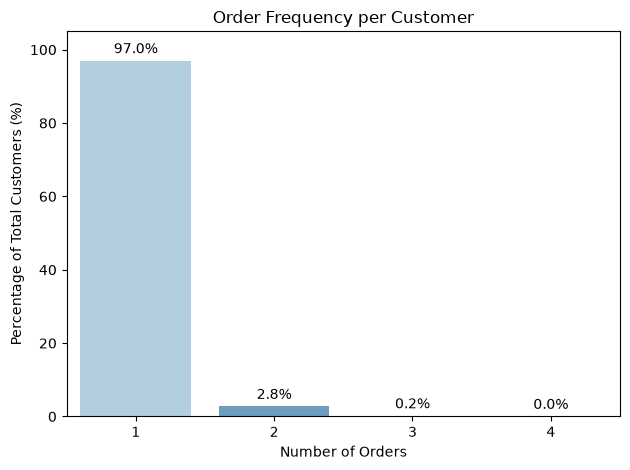

In [105]:
ax = sns.barplot(
    data=orders_summary.head(4), 
    x='order_count', 
    y='percentage', 
    palette='Blues_d', 
    hue='order_count', 
    legend=False
)

plt.title('Order Frequency per Customer')
plt.xlabel('Number of Orders')
plt.ylabel('Percentage of Total Customers (%)')
plt.ylim(0, 105)

for p in ax.patches: 
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', xytext=(0, 3), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

Insight:

97.0% of customers place only a single order, indicating an extreme reliance on continuous top-of-funnel acquisition.

Repeat customer rate is capped at just 3.0% (2.8% making 2 purchases, 0.2% making 3), highlighting an immediate opportunity for targeted post-purchase retention strategies.

Actionable Strategy:

Set up trigger-based email and push notification flows at 30, 60, and 90 days post-purchase offering personalized product recommendations or cross-category discounts.

6.Churn-Rate by Top 10 Product Categories

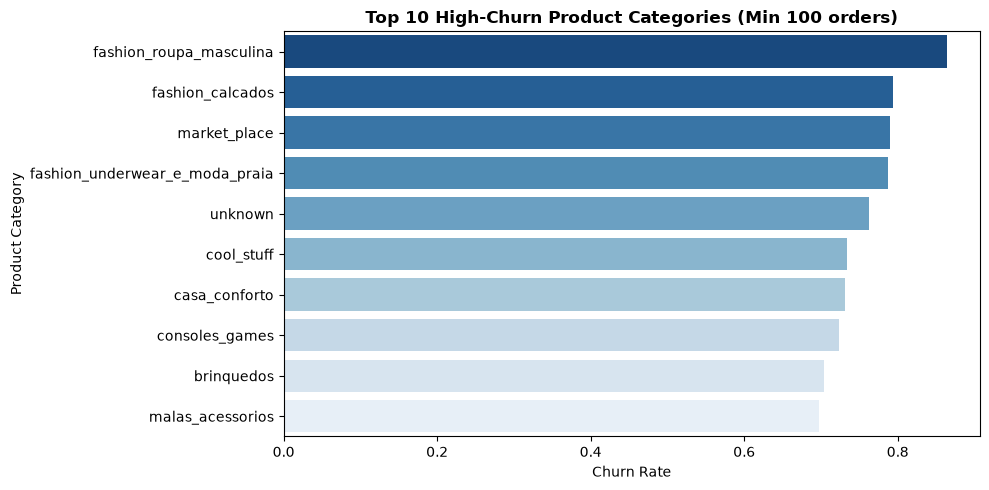

In [106]:
category_churn = master_df.groupby('product_category_name')['is_churned'].agg(['mean', 'count']).reset_index()

top_categories = category_churn[category_churn['count'] > 100].sort_values(by='mean', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_categories, 
    y='product_category_name', 
    x='mean', 
    hue='product_category_name', 
    palette='Blues_r'
)

plt.title('Top 10 High-Churn Product Categories (Min 100 orders)', weight='bold') 
plt.xlabel('Churn Rate') 
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

7.Geographic Distribution of Churn

In [107]:
state_churn = master_df.groupby('customer_state')['is_churned'].mean().sort_values(ascending=False).head(10).reset_index()

/var/folders/xx/bkcz2kt91wz4tlrp0kj_x4r40000gn/T/ipykernel_7037/2382087784.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_churn, x='customer_state', y='is_churned', palette='magma')


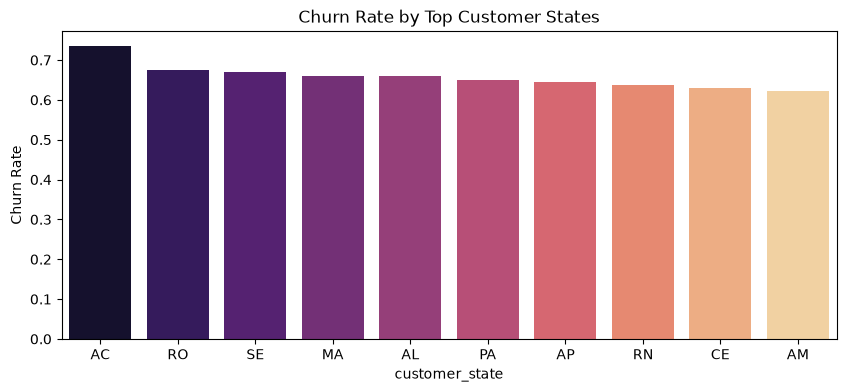

In [108]:
plt.figure(figsize=(10, 4)) 
sns.barplot(data=state_churn, x='customer_state', y='is_churned', palette='magma') 
plt.title('Churn Rate by Top Customer States') 
plt.ylabel('Churn Rate') 
plt.show()

8.Total Revenue Lost to Churn

In [109]:
lost_revenue = master_df[master_df['is_churned'] == 1]['total_payment_value'].sum()
retained_revenue = master_df[master_df['is_churned'] == 0]['total_payment_value'].sum()

print(f"Total Lost Revenue (Churned): ${lost_revenue:,.2f}")
print(f"Total Retained Revenue (Active): ${retained_revenue:,.2f}")

Total Lost Revenue (Churned): $11,423,901.42
Total Retained Revenue (Active): $8,328,291.88


Connecting olist_master_clean.csv into a PostgreSQL table

In [110]:
DB_USER = 'postgres'
DB_PASSWORD = 'root'  
DB_HOST = 'localhost'
DB_PORT = '5432'
DB_NAME = 'ecommerce_db'

In [111]:
engine = create_engine(f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')

In [112]:
master_df.to_sql('fact_orders', engine, if_exists='replace', index=False)

91

Saving Master CSV for PostgreSQL & Tableau

In [114]:
master_df.to_csv('../data/olist_master_clean.csv', index=False)